# Strait of Hormuz 2026 - Shipping Crisis Analysis

A before vs after look at the Strait of Hormuz closure on 2026-02-28.
The data has 125 daily rows (Jan 1 to May 5, 2026): 58 days of `pre_war` and 67 days of `war_crisis`, with no missing values.

Dataset: `datasets/strait_of_hormuz_shipping_disruption_2026 (1).csv`

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

In [23]:
# Load dataset and order by date
df = pd.read_csv("datasets/strait_of_hormuz_shipping_disruption_2026 (1).csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# New column: Brent-WTI spread
df["brent_wti_spread"] = df["brent_crude_usd_bbl"] - df["wti_crude_usd_bbl"]

CLOSURE = df.loc[df["period_type"] == "war_crisis", "date"].min()
print("Closure date (t=0):", CLOSURE.date())
print("Observations:", len(df), "| Period:", df.date.min().date(), "->", df.date.max().date())
df.head()

Closure date (t=0): 2026-02-28
Observations: 125 | Period: 2026-01-01 -> 2026-05-05


,date,period_type,days_since_closure,daily_ship_transits,monthly_vessel_count,monthly_count_is_exact,transit_pct_of_prewar_avg,oil_throughput_mbpd,lng_throughput_bcfd,brent_crude_usd_bbl,wti_crude_usd_bbl,vessels_attacked_cumulative,new_attacks_today,attack_type,vessels_stranded_in_gulf,maersk_status,cma_cgm_status,hapag_lloyd_status,cosco_status,msc_status,iran_approved_flags,war_risk_insurance_pct,cape_reroute_extra_days,diesel_usd_gallon_us,key_event,source_citation,brent_wti_spread
0,2026-01-01,pre_war,0,103,3000,False,100.0,19.7,10.3,75.29,72.06,0,0,none,0,operating,operating,operating,operating,operating,all,0.125,0,3.27,Normal operations,EIA; IEA; Lloyd's List,3.23
1,2026-01-02,pre_war,0,108,3000,False,100.0,19.5,10.3,75.75,72.06,0,0,none,0,operating,operating,operating,operating,operating,all,0.125,0,3.28,Normal operations,EIA; IEA; Lloyd's List,3.69
2,2026-01-03,pre_war,0,108,3000,False,100.0,19.7,10.6,75.97,72.27,0,0,none,0,operating,operating,operating,operating,operating,all,0.125,0,3.37,Normal operations,EIA; IEA; Lloyd's List,3.70
3,2026-01-04,pre_war,0,108,3000,False,100.0,19.8,10.3,75.18,71.26,0,0,none,0,operating,operating,operating,operating,operating,all,0.125,0,3.39,Normal operations,EIA; IEA; Lloyd's List,3.92
4,2026-01-05,pre_war,0,98,3000,False,100.0,19.9,10.4,74.95,71.67,0,0,none,0,operating,operating,operating,operating,operating,all,0.125,0,3.29,Normal operations,EIA; IEA; Lloyd's List,3.28


## 1. Size of the shock (before vs after)

In [24]:
metrics = ["daily_ship_transits","oil_throughput_mbpd","lng_throughput_bcfd",
           "brent_crude_usd_bbl","wti_crude_usd_bbl","brent_wti_spread",
           "war_risk_insurance_pct","diesel_usd_gallon_us",
           "vessels_stranded_in_gulf","cape_reroute_extra_days"]

summary = df.groupby("period_type")[metrics].mean().T
summary = summary[["pre_war","war_crisis"]]
summary["change_%"] = ((summary["war_crisis"] / summary["pre_war"] - 1) * 100).round(1)
summary = summary.round(2)
summary

period_type,pre_war,war_crisis,change_%
daily_ship_transits,102.69,5.78,-94.4
oil_throughput_mbpd,19.97,1.24,-93.8
lng_throughput_bcfd,10.47,0.60,-94.3
brent_crude_usd_bbl,72.35,99.75,37.9
wti_crude_usd_bbl,68.66,96.16,40.1
brent_wti_spread,3.69,3.59,-2.8
war_risk_insurance_pct,0.16,3.75,2239.4
diesel_usd_gallon_us,3.33,4.87,46.2
vessels_stranded_in_gulf,0.00,414.04,inf
cape_reroute_extra_days,0.00,14.00,inf


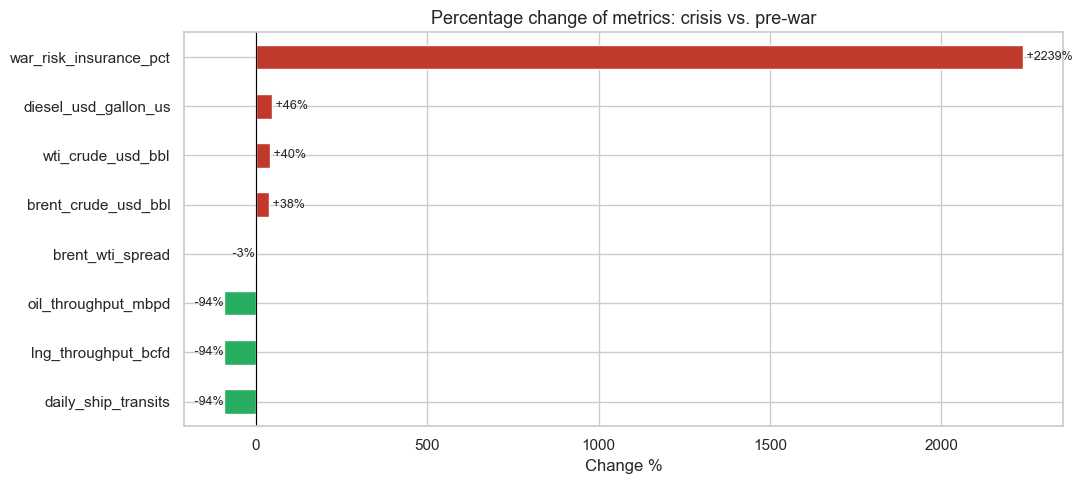

In [25]:
# Percentage change, only for metrics with a non-zero base
plot_df = summary[summary["pre_war"] != 0].copy().sort_values("change_%")
colors = ["#c0392b" if v > 0 else "#27ae60" for v in plot_df["change_%"]]
ax = plot_df["change_%"].plot(kind="barh", color=colors)
ax.set_title("Percentage change of metrics: crisis vs. pre-war")
ax.set_xlabel("Change %")
ax.axvline(0, color="black", lw=0.8)
for i, v in enumerate(plot_df["change_%"]):
    ax.text(v, i, f" {v:+.0f}%", va="center", ha="left" if v>=0 else "right", fontsize=9)
plt.tight_layout(); plt.show()

## 2. How each variable moved over time

The dashed line marks the closure date. Transits and throughput drop almost at once, while prices and insurance react more slowly.

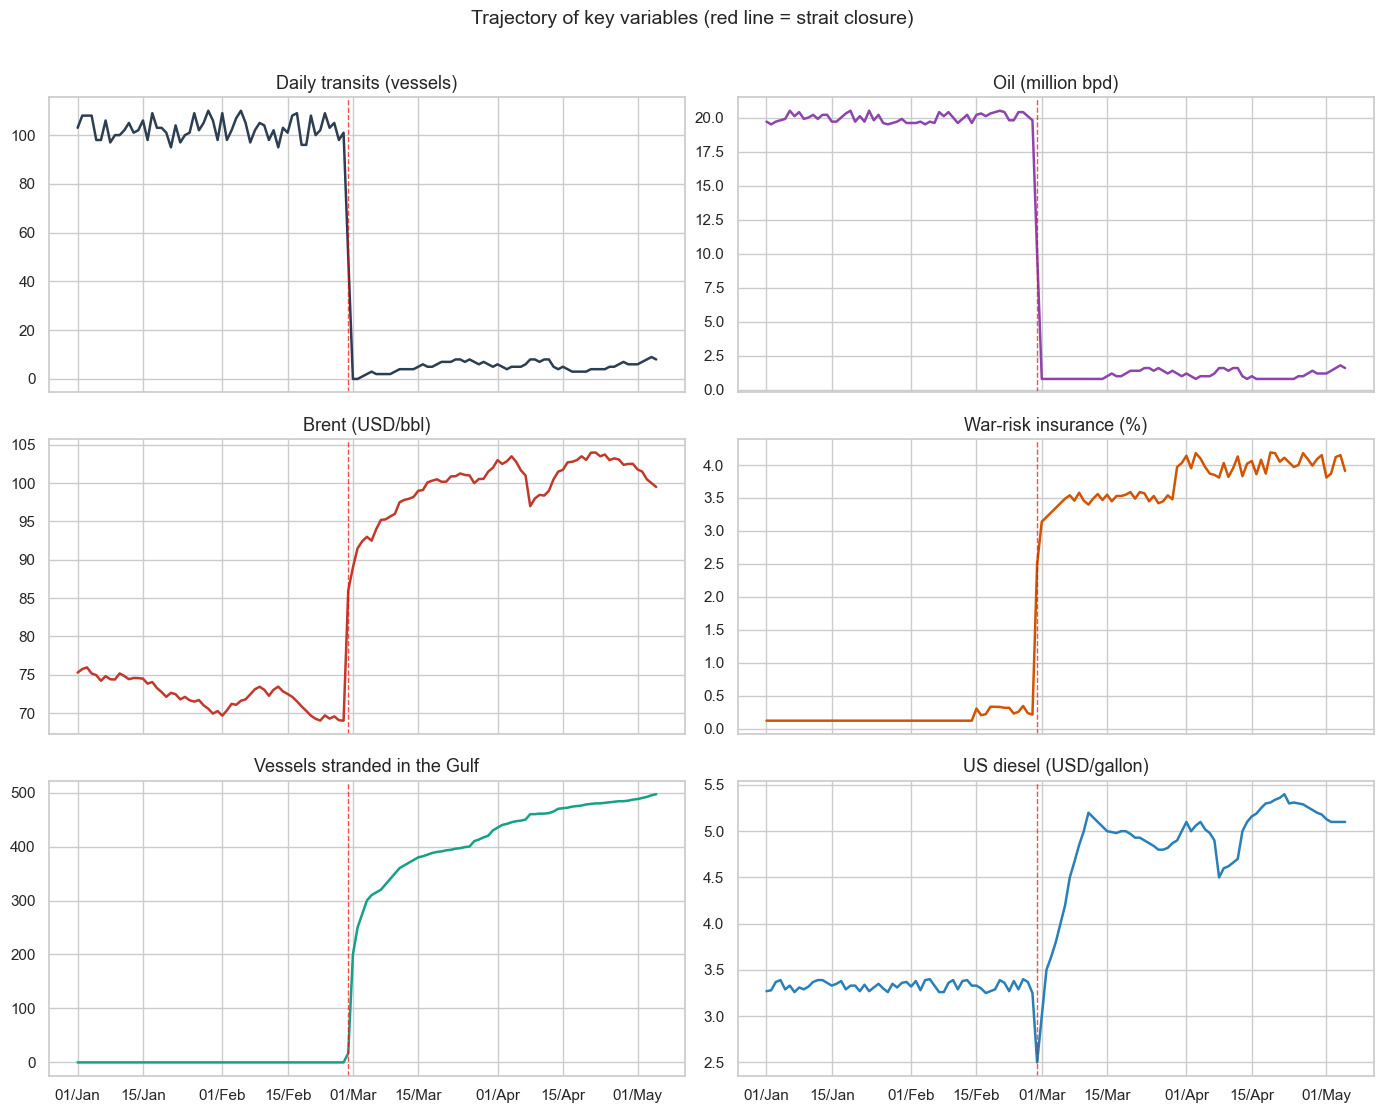

In [26]:
fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
series = [
    ("daily_ship_transits", "Daily transits (vessels)", "#2c3e50"),
    ("oil_throughput_mbpd", "Oil (million bpd)", "#8e44ad"),
    ("brent_crude_usd_bbl", "Brent (USD/bbl)", "#c0392b"),
    ("war_risk_insurance_pct", "War-risk insurance (%)", "#d35400"),
    ("vessels_stranded_in_gulf", "Vessels stranded in the Gulf", "#16a085"),
    ("diesel_usd_gallon_us", "US diesel (USD/gallon)", "#2980b9"),
]
for ax, (col, title, cor) in zip(axes.ravel(), series):
    ax.plot(df["date"], df[col], color=cor, lw=1.8)
    ax.axvline(CLOSURE, color="red", ls="--", lw=1, alpha=0.7)
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))
fig.suptitle("Trajectory of key variables (red line = strait closure)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

Trough: 0.0 % | Last day: 8.0 %


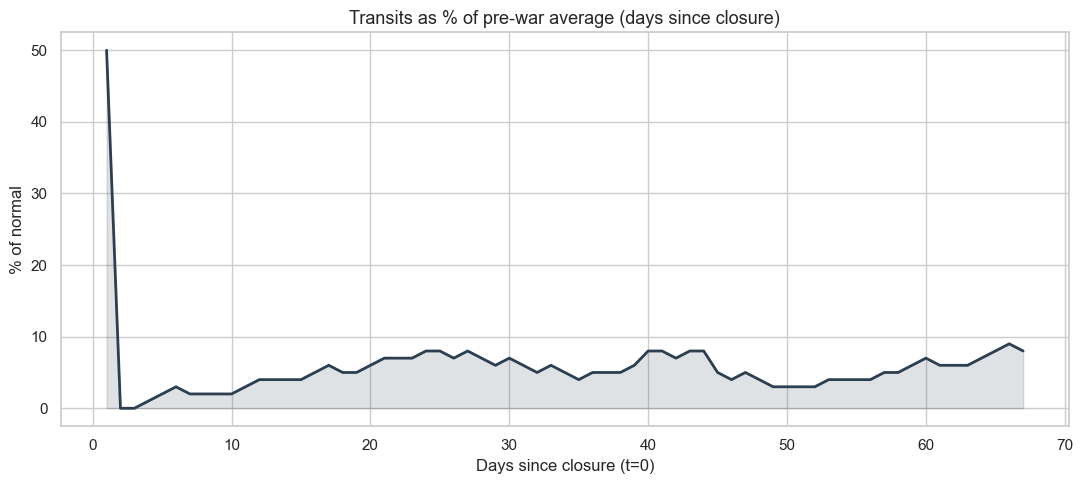

In [27]:
# Partial recovery within the crisis: transits as % of the pre-war average
war = df[df["period_type"]=="war_crisis"]
ax = plt.subplot()
ax.plot(war["days_since_closure"], war["transit_pct_of_prewar_avg"], color="#2c3e50", lw=2)
ax.fill_between(war["days_since_closure"], war["transit_pct_of_prewar_avg"], alpha=0.15, color="#2c3e50")
ax.set_title("Transits as % of pre-war average (days since closure)")
ax.set_xlabel("Days since closure (t=0)"); ax.set_ylabel("% of normal")
print("Trough:", war['transit_pct_of_prewar_avg'].min(), "% | Last day:", war['transit_pct_of_prewar_avg'].iloc[-1], "%")
plt.tight_layout(); plt.show()

## 3. Did insurance react first?

The idea: maybe the war-risk insurance premium goes up before transits collapse, working as an early warning. We check this with a zoom on the days around the closure and a lagged correlation. As the result below shows, the data does not really support that idea.

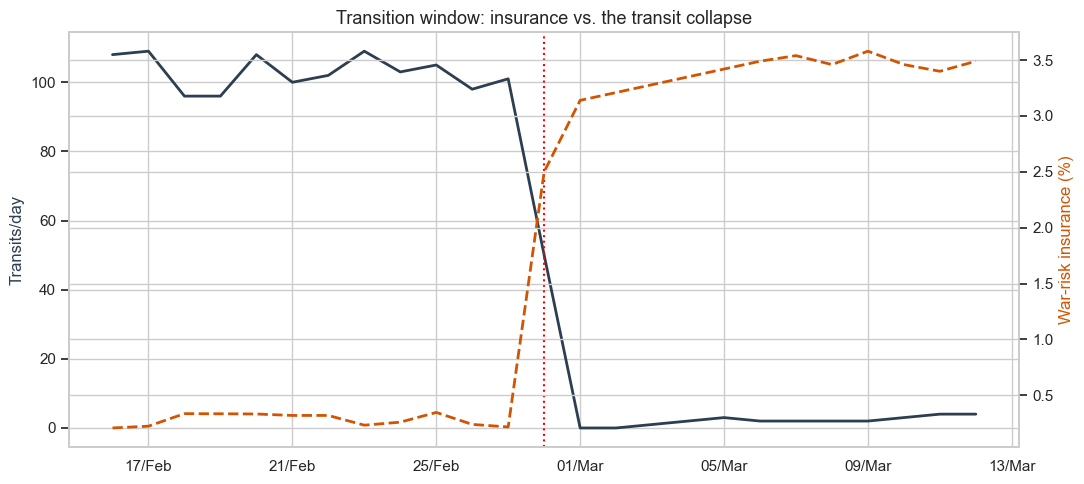

Last 7 pre-war days:
      date  war_risk_insurance_pct  daily_ship_transits
2026-02-21                   0.320                  100
2026-02-22                   0.320                  102
2026-02-23                   0.233                  109
2026-02-24                   0.260                  103
2026-02-25                   0.347                  105
2026-02-26                   0.240                   98
2026-02-27                   0.217                  101


In [28]:
window = df[(df["date"] >= CLOSURE - pd.Timedelta(days=12)) &
            (df["date"] <= CLOSURE + pd.Timedelta(days=12))]

fig, ax1 = plt.subplots()
ax1.plot(window["date"], window["daily_ship_transits"], color="#2c3e50", lw=2, label="Transits/day")
ax1.set_ylabel("Transits/day", color="#2c3e50")
ax2 = ax1.twinx()
ax2.plot(window["date"], window["war_risk_insurance_pct"], color="#d35400", lw=2, ls="--", label="Insurance (%)")
ax2.set_ylabel("War-risk insurance (%)", color="#d35400")
ax1.axvline(CLOSURE, color="red", ls=":", lw=1.5)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))
ax1.set_title("Transition window: insurance vs. the transit collapse")
plt.tight_layout(); plt.show()

# Insurance over the final pre-war days
pre_end = df[df["period_type"]=="pre_war"].tail(7)[["date","war_risk_insurance_pct","daily_ship_transits"]]
print("Last 7 pre-war days:"); print(pre_end.to_string(index=False))

In [29]:
# Lagged correlation: insurance(t-k) vs transits(t). A positive lag means insurance leads.
s_ins = df["war_risk_insurance_pct"]
s_tra = df["daily_ship_transits"]
print("Correlation insurance(t-k) x transits(t):")
for k in range(0, 6):
    c = s_ins.shift(k).corr(s_tra)
    print(f"  lag {k}d: {c:+.3f}")
print("\nReading: the correlation is strongest at lag 0 and gets weaker as the lag grows, so insurance moves at the same time as transits, not before. The premium rose a\nlittle in the last pre-war week (about 2x the 0.12% floor) but with no clear ramp, and even dipped at the end. In this dataset insurance was not a reliable early\nwarning; the closure was a sudden shock from outside the market.")

Correlation insurance(t-k) x transits(t):
  lag 0d: -0.989
  lag 1d: -0.983
  lag 2d: -0.966
  lag 3d: -0.950
  lag 4d: -0.934
  lag 5d: -0.917

Reading: the correlation is strongest at lag 0 and gets weaker as the lag grows, so insurance moves at the same time as transits, not before. The premium rose a
little in the last pre-war week (about 2x the 0.12% floor) but with no clear ramp, and even dipped at the end. In this dataset insurance was not a reliable early
warning; the closure was a sudden shock from outside the market.


## 4. Price pass-through

(a) less oil throughput against the Brent price. (b) Brent against US retail diesel. Two simple linear fits with R-squared.

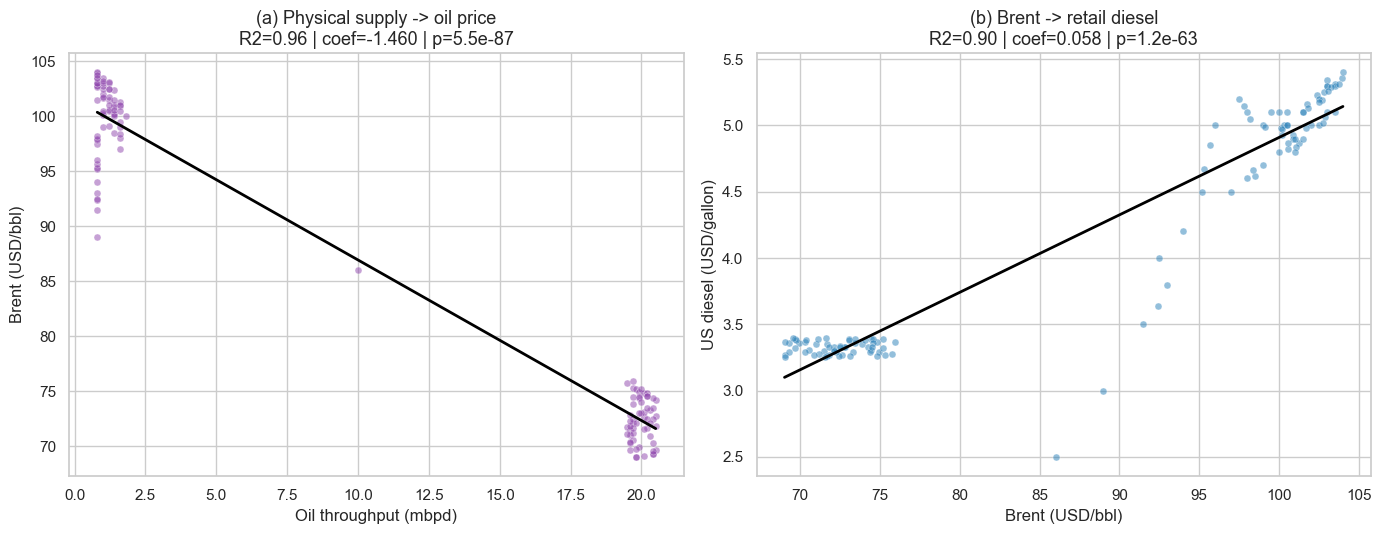

In [30]:
def regplot(ax, x, y, xlabel, ylabel, title, cor):
    m, b, r, p, se = stats.linregress(x, y)
    ax.scatter(x, y, alpha=0.5, s=25, color=cor, edgecolor="white", linewidth=0.4)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, m*xs + b, color="black", lw=2)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(f"{title}\nR2={r**2:.2f} | coef={m:.3f} | p={p:.1e}")
    return m, r**2, p

fig, (axa, axb) = plt.subplots(1, 2, figsize=(14, 5.5))
regplot(axa, df["oil_throughput_mbpd"], df["brent_crude_usd_bbl"],
        "Oil throughput (mbpd)", "Brent (USD/bbl)",
        "(a) Physical supply -> oil price", "#8e44ad")
regplot(axb, df["brent_crude_usd_bbl"], df["diesel_usd_gallon_us"],
        "Brent (USD/bbl)", "US diesel (USD/gallon)",
        "(b) Brent -> retail diesel", "#2980b9")
plt.tight_layout(); plt.show()

## 5. What each carrier did

Western carriers (Maersk, CMA CGM, Hapag-Lloyd, MSC) compared with COSCO (Chinese), alongside the `iran_approved_flags` column.

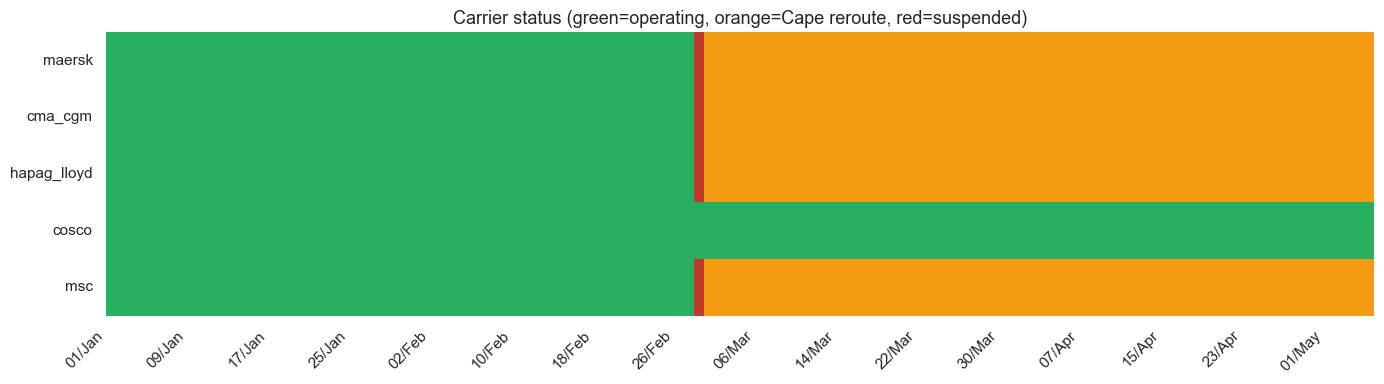

COSCO - unique statuses: <ArrowStringArray>
['operating']
Length: 1, dtype: str
Iran-approved flags (during the crisis):
iran_approved_flags
China;Russia;India;Iraq;Pakistan;Malaysia;Thailand;Philippines    34
China                                                             22
China;Russia;India;Iraq;Pakistan;Malaysia;Thailand                 7
none                                                               4


In [31]:
carriers = ["maersk_status","cma_cgm_status","hapag_lloyd_status","cosco_status","msc_status"]
mapping = {"operating": 0, "rerouted_cape": 1, "suspended": 2}
status_num = df[carriers].apply(lambda c: c.map(mapping))
status_num.index = df["date"]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(status_num.T, cmap=["#27ae60","#f39c12","#c0392b"], cbar=False,
            ax=ax, yticklabels=[c.replace("_status","") for c in carriers])
ax.set_title("Carrier status (green=operating, orange=Cape reroute, red=suspended)")
step = max(1, len(df)//15)
ax.set_xticks(np.arange(0, len(df), step))
ax.set_xticklabels([d.strftime("%d/%b") for d in df["date"].iloc[::step]], rotation=45, ha="right")
ax.set_xlabel("")
plt.tight_layout(); plt.show()

print("COSCO - unique statuses:", df["cosco_status"].unique())
print("Iran-approved flags (during the crisis):")
print(df[df.period_type=='war_crisis']['iran_approved_flags'].value_counts().to_string())

## 6. Attacks over time

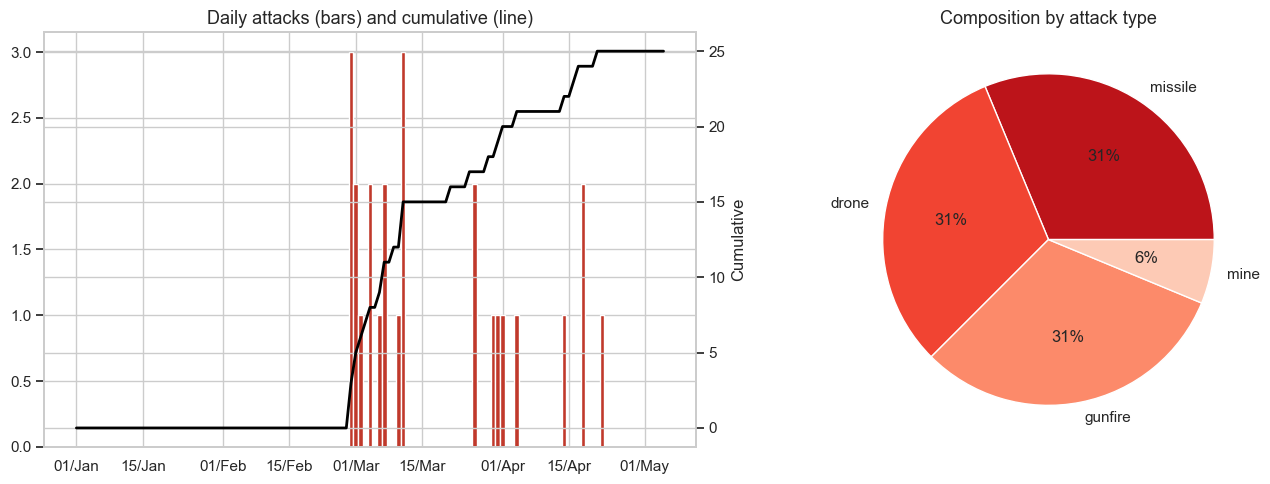

Total attacks: 25 | Peak stranded: 497


In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(df["date"], df["new_attacks_today"], color="#c0392b", width=1.0)
ax1b = ax1.twinx()
ax1b.plot(df["date"], df["vessels_attacked_cumulative"], color="black", lw=2)
ax1.set_title("Daily attacks (bars) and cumulative (line)")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))
ax1b.set_ylabel("Cumulative")

types = df[df["attack_type"]!="none"]["attack_type"].value_counts()
ax2.pie(types, labels=types.index, autopct="%1.0f%%", colors=sns.color_palette("Reds_r", len(types)))
ax2.set_title("Composition by attack type")
plt.tight_layout(); plt.show()
print("Total attacks:", int(df["new_attacks_today"].sum()),
      "| Peak stranded:", int(df["vessels_stranded_in_gulf"].max()))

## 7. Brent-WTI spread

A supply shock outside the US tends to widen the gap between Brent and WTI.

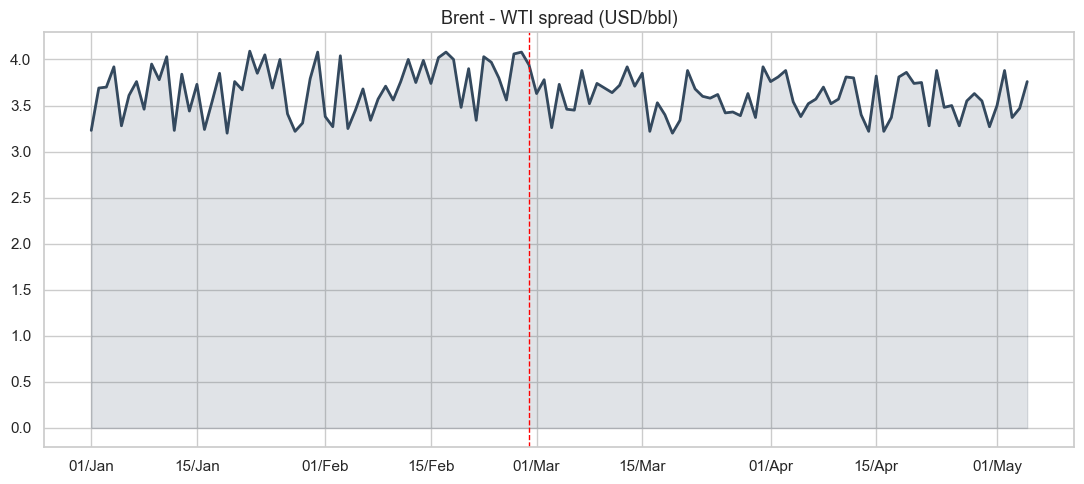

Mean spread - pre-war: 3.69 | crisis: 3.59


In [33]:
ax = plt.subplot()
ax.plot(df["date"], df["brent_wti_spread"], color="#34495e", lw=2)
ax.fill_between(df["date"], df["brent_wti_spread"], alpha=0.15, color="#34495e")
ax.axvline(CLOSURE, color="red", ls="--", lw=1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))
ax.set_title("Brent - WTI spread (USD/bbl)")
plt.tight_layout(); plt.show()
print("Mean spread - pre-war: %.2f | crisis: %.2f" % (
    df[df.period_type=='pre_war'].brent_wti_spread.mean(),
    df[df.period_type=='war_crisis'].brent_wti_spread.mean()))

## 8. Correlation matrix

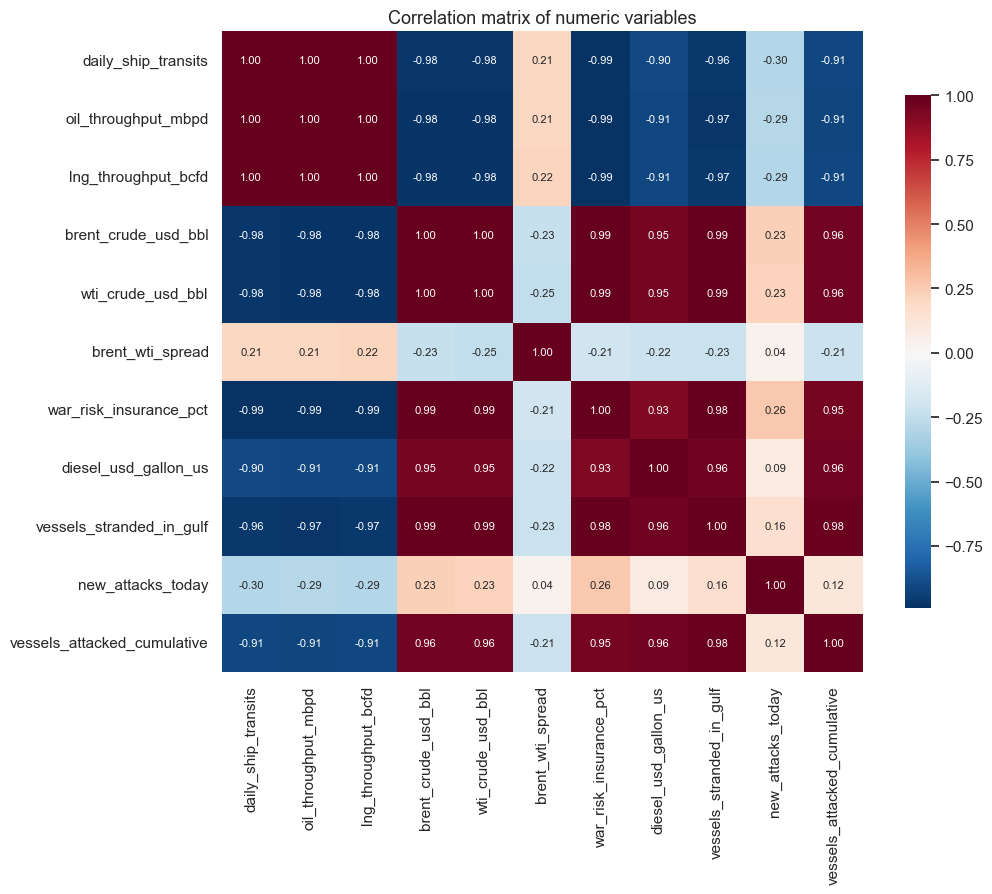

In [34]:
num = ["daily_ship_transits","oil_throughput_mbpd","lng_throughput_bcfd",
       "brent_crude_usd_bbl","wti_crude_usd_bbl","brent_wti_spread",
       "war_risk_insurance_pct","diesel_usd_gallon_us","vessels_stranded_in_gulf",
       "new_attacks_today","vessels_attacked_cumulative"]
corr = df[num].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink":0.8}, ax=ax, annot_kws={"size":8})
ax.set_title("Correlation matrix of numeric variables")
plt.tight_layout(); plt.show()

## 9. Petrobras (PETR4) during the crisis

A crisis that pushes oil up should help an oil producer. Here we add the real PETR4 share price (from yfinance), line it up with the same dates, and look at how the stock behaved around the closure and how closely it followed Brent.

Trading days matched: 83


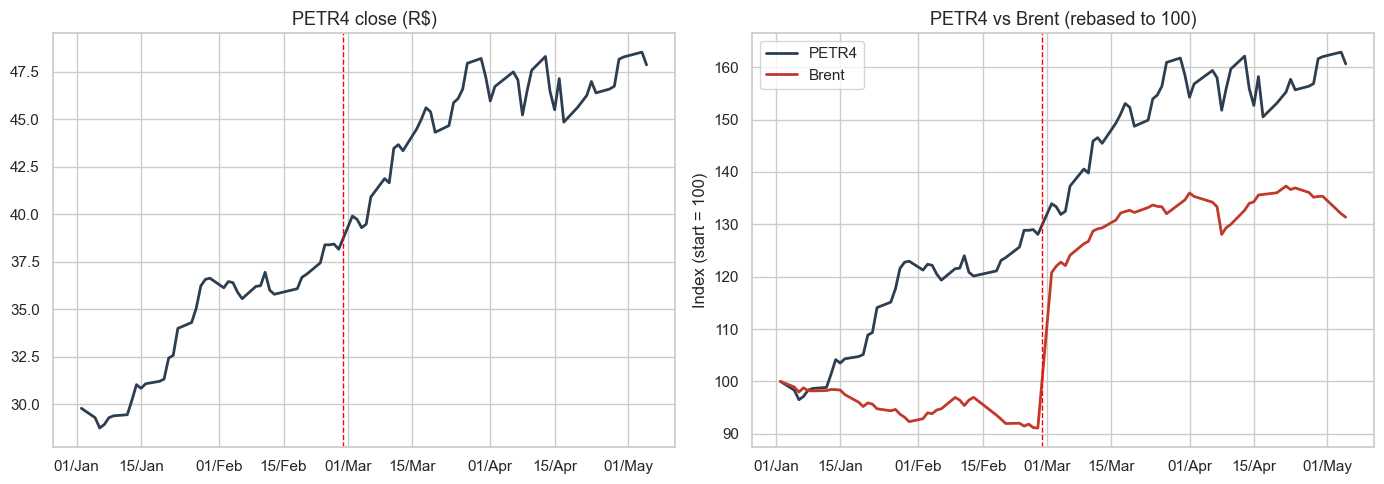

In [35]:
import yfinance as yf

# Real Petrobras share price (PETR4.SA), aligned to the dataset window
petr = yf.download("PETR4.SA", start="2026-01-01", end="2026-05-06",
                   progress=False, auto_adjust=True)["Close"].squeeze()
petr.name = "petr4"
petr.index = petr.index.tz_localize(None)

m = df.merge(petr.rename_axis("date").reset_index(), on="date", how="inner")  # trading days only
m["petr4_ret"] = m["petr4"].pct_change()
print("Trading days matched:", len(m))

fig, (axl, axr) = plt.subplots(1, 2, figsize=(14, 5))
axl.plot(m["date"], m["petr4"], color="#2c3e50", lw=2)
axl.axvline(CLOSURE, color="red", ls="--", lw=1)
axl.set_title("PETR4 close (R$)")
axl.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))

# Rebased to 100 on the first day, to compare how far each one moved
base = m.iloc[0]
axr.plot(m["date"], m["petr4"] / base["petr4"] * 100, color="#2c3e50", lw=2, label="PETR4")
axr.plot(m["date"], m["brent_crude_usd_bbl"] / base["brent_crude_usd_bbl"] * 100, color="#c0392b", lw=2, label="Brent")
axr.axvline(CLOSURE, color="red", ls="--", lw=1)
axr.set_title("PETR4 vs Brent (rebased to 100)")
axr.set_ylabel("Index (start = 100)")
axr.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))
axr.legend()
plt.tight_layout(); plt.show()

In [37]:
from scipy import stats

pre = m[m["period_type"] == "pre_war"]
war = m[m["period_type"] == "war_crisis"]

print("PETR4 return, whole window : %+.1f%%" % ((m["petr4"].iloc[-1] / m["petr4"].iloc[0] - 1) * 100))
print("PETR4 return, pre-war      : %+.1f%%" % ((pre["petr4"].iloc[-1] / pre["petr4"].iloc[0] - 1) * 100))
print("PETR4 return, crisis       : %+.1f%%" % ((war["petr4"].iloc[-1] / war["petr4"].iloc[0] - 1) * 100))
print("Daily volatility pre/crisis: %.2f%% / %.2f%%" % (pre["petr4_ret"].std() * 100, war["petr4_ret"].std() * 100))

# Level correlation (shared trend) vs daily-return beta (day-to-day co-movement)
m["brent_ret"] = m["brent_crude_usd_bbl"].pct_change()
d2 = m.dropna(subset=["petr4_ret", "brent_ret"])
beta, a, r, pv, se = stats.linregress(d2["brent_ret"], d2["petr4_ret"])
print("\nLevel correlation PETR4 x Brent : %.2f" % m["petr4"].corr(m["brent_crude_usd_bbl"]))
print("Daily-return beta PETR4 vs Brent: %.2f (R2=%.2f)" % (beta, r ** 2))

PETR4 return, whole window : +60.6%
PETR4 return, pre-war      : +28.1%
PETR4 return, crisis       : +19.9%
Daily volatility pre/crisis: 1.55% / 2.19%

Level correlation PETR4 x Brent : 0.89
Daily-return beta PETR4 vs Brent: 0.14 (R2=0.07)
